# Build and train a **random forest** classificationd

## Data preprocessing

In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [84]:
dataset = pd.read_csv("Social_Network_Ads.csv")
x = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [85]:
# Spliting the dataset into the training set and the test set
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=0)

In [86]:
y_test[:10]

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0])

In [87]:
# Feature scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

## Model train and prediction

In [88]:
from sklearn.ensemble import RandomForestClassifier
forest_model = RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=0)
forest_model.fit(x_train_scaled, y_train)

RandomForestClassifier(criterion='entropy', n_estimators=10, random_state=0)

In [89]:
y_pred = forest_model.predict(x_test_scaled)

In [90]:
np.concatenate((y_test.reshape(-1, 1), y_pred.reshape(-1, 1)), 1)[:10, :]

array([[0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 1]])

## Model evaluation

In [91]:
from sklearn.metrics import confusion_matrix, accuracy_score
import plotly.graph_objects as go

print(f"Model accuracy is: {accuracy_score(y_test, y_pred)}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the Confusion matrix on plotly
fig_2 = go.Figure(data=go.Heatmap(z=cm,
                                  text=cm,
                                  texttemplate="%{text}",
                                  colorscale="Blues",
                                  colorbar_title="Value"))
fig_2.update_layout(width=500,
                    yaxis=dict(title="True Labels",
                               autorange='reversed'),
                    title="Confusion matrix for Random Forest classification model",
                    xaxis_title="Prediction Labels")
fig_2.show()

Model accuracy is: 0.91


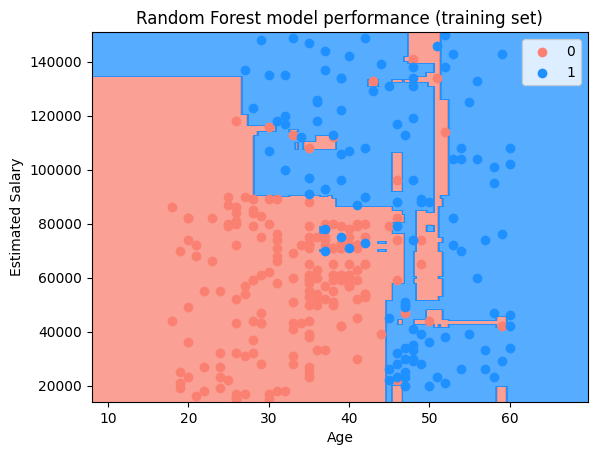

In [92]:
from matplotlib.colors import ListedColormap
X_set, y_set = x_train, y_train
X1, X2 = np.meshgrid(np.arange(start=X_set[:, 0].min()-10, stop=X_set[:, 0].max()+10, step=0.25),
                     np.arange(start=X_set[:, 1].min()-1000, stop=X_set[:, 1].max()+1000, step=5))
plt.contourf(X1, X2, forest_model.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha=0.75, cmap=ListedColormap(("salmon", "dodgerblue")))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_set)):
  plt.scatter(X_set[y_set==j, 0], X_set[y_set==j, 1], color=ListedColormap(("salmon", "dodgerblue"))(i), label=j)
plt.title("Random Forest model performance (training set)")
plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.legend()
plt.show()

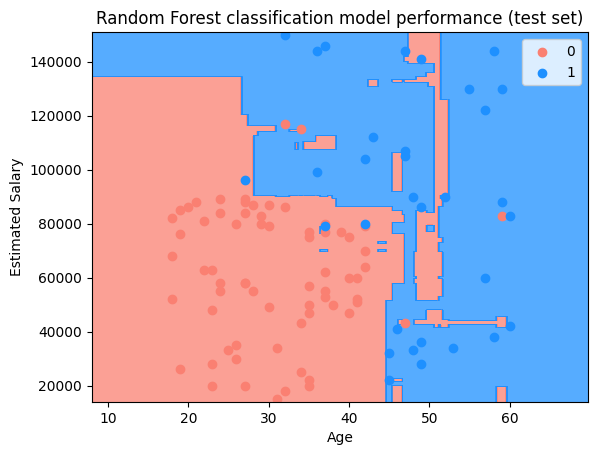

In [93]:
from matplotlib.colors import ListedColormap
X_set, y_set = x_test, y_test
X1, X2 = np.meshgrid(np.arange(start=X_set[:, 0].min()-10, stop=X_set[:, 0].max()+10, step=0.25),
                     np.arange(start=X_set[:, 1].min()-1000, stop=X_set[:, 1].max()+1000, step=5))
plt.contourf(X1, X2, forest_model.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha=0.75, cmap=ListedColormap(("salmon", "dodgerblue")))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_set)):
  plt.scatter(X_set[y_set==j, 0], X_set[y_set==j, 1], color=ListedColormap(("salmon", "dodgerblue"))(i), label=j)
plt.title("Random Forest classification model performance (test set)")
plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.legend()
plt.show()